In [14]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from xgboost.sklearn import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

In [20]:
# Data Loading
df = pd.read_csv("insurance.csv")
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [24]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


Text(0.5, 1.0, 'Distribution of charges by age and sex')

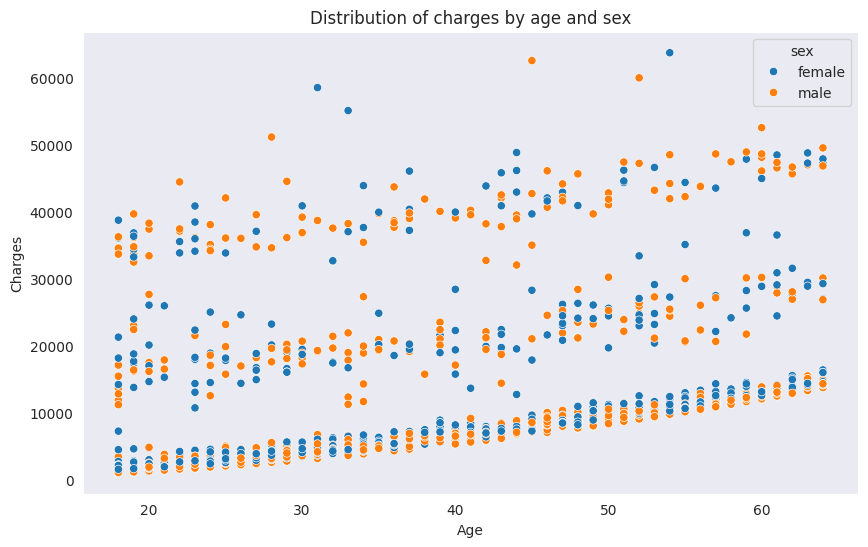

In [25]:
#Exploratory Data Analysis
sns.set_style("dark")
plt.figure(figsize = (10,6))

sns.scatterplot(x=df['age'], y=df['charges'], hue=df['sex'],data=df)
plt.xlabel("Age")
plt.ylabel("Charges")
plt.title("Distribution of charges by age and sex")

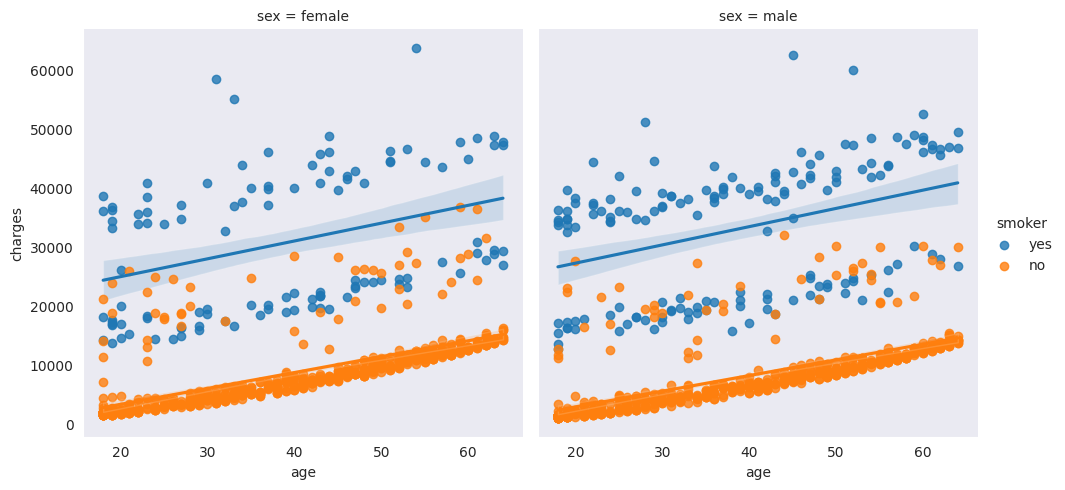

In [26]:
sns.lmplot(data=df, x="age", y="charges", hue="smoker",col="sex",height=5)

<Axes: xlabel='region', ylabel='charges'>

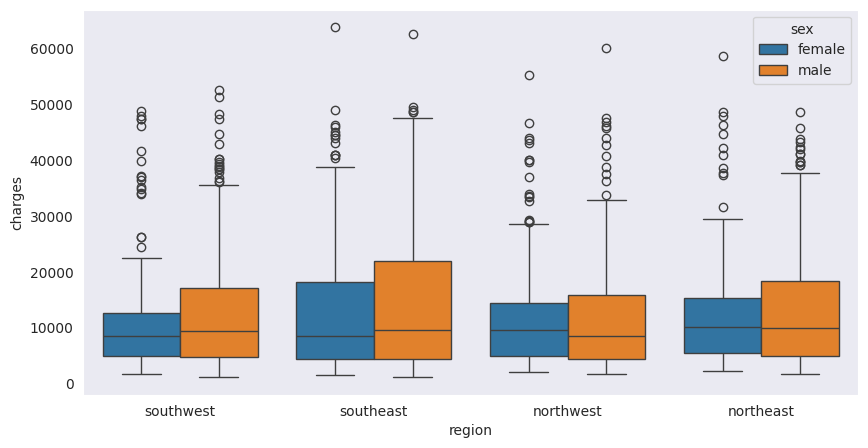

In [27]:
#Boxplot to analyse charges by region and sex
plt.figure(figsize=(10,5))
sns.boxplot(x='region', y='charges', hue='sex', data=df)

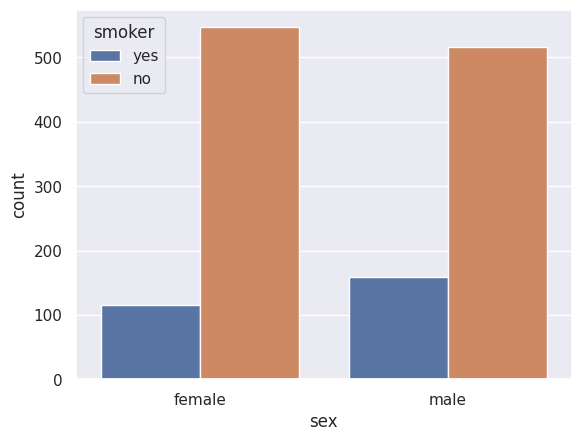

In [28]:
sns.set_theme(style="darkgrid")
ax=sns.countplot(x="sex",hue="smoker",data=df)

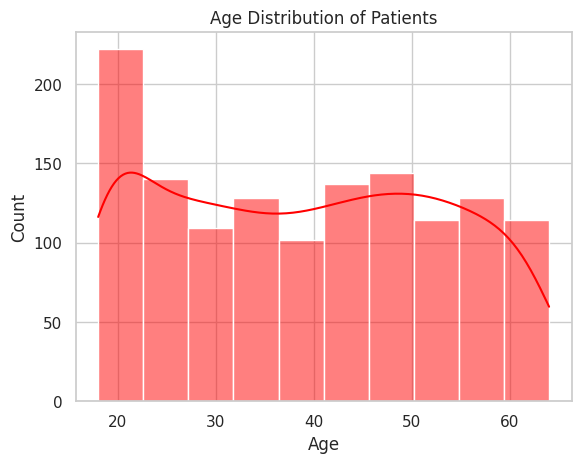

In [29]:
#Visualising target variable
sns.set_style('whitegrid')
#plot of histogram for age
sns.histplot(data=df['age'], kde=True, color='red', bins=10)
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.show()

In [16]:
# Preprocessing: Prepare the data for model training.

# Encoding categorical variables: Convert categorical features into numerical format using one-hot encoding.
# This is necessary because most machine learning models cannot directly process categorical text data.
df_encoded = pd.get_dummies(df, drop_first=False)

# Separate features (X) and target variable (y): 'charges' is the target variable we want to predict.
X = df_encoded.drop(['charges'], axis=1)
y = df_encoded["charges"]

# Splitting data into training and testing sets: Divide the data into sets for training and evaluating the model.
# 80% of the data will be used for training and 20% for testing, with a fixed random state for reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
# Model Training: Define and train the regression models.

# Gradient Boosting Regressor: Initialize and train a Gradient Boosting model.
m2 = GradientBoostingRegressor(random_state=42)
m2.fit(X_train, y_train)
# Make predictions on the training and testing data.
train_predict2 = m2.predict(X_train)
test_predict2 = m2.predict(X_test)

# XGBoost Regressor: Initialize and train an XGBoost model.
model = XGBRegressor(random_state=42)
model.fit(X_train, y_train)
# Make predictions on the training and testing data.
training_data_prediction = model.predict(X_train)
test_data_prediction = model.predict(X_test)

In [18]:
# Evaluation: Evaluate the performance of the trained models using various metrics.

# Evaluation: Gradient Boosting Regressor
print("\n          ---------------------------------------------------TRAINING SET (GBM)--------------------------------------------------------    \n")
# Calculate R-squared: Measures the proportion of the variance in the dependent variable that is predictable from the independent variables.
s12 = metrics.r2_score(y_train, train_predict2)
# Calculate Mean Absolute Error (MAE): The average of the absolute differences between predicted and actual values.
s22 = metrics.mean_absolute_error(y_train, train_predict2)
# Calculate Mean Squared Error (MSE): The average of the squared differences between predicted and actual values.
mse2_train = metrics.mean_squared_error(y_train, train_predict2)
# Calculate Root Mean Square Error (RMSE): The square root of the MSE, providing an error metric in the same units as the target variable.
score4_train = np.sqrt(mse2_train)
# Calculate Mean Absolute Percentage Error (MAPE): Measures the accuracy as a percentage of the error.
score31_train = metrics.mean_absolute_percentage_error(y_train, train_predict2)
print("\t  R squared Error :", s12)
print("\t  Mean Absolute Error :", s22)
print('\t  Mean Absolute Percentage Error : ', score31_train)
print("\t  Root Mean Square Error : ", score4_train)
print("\n          -----------------------------------------------------------------------------------------------------------------------   \n")

print("\n          ---------------------------------------------------TEST SET (GBM)--------------------------------------------------------    \n")
# Calculate R-squared for test set.
s_12 = metrics.r2_score(y_test, test_predict2)
# Calculate MAE for test set.
s_22 = metrics.mean_absolute_error(y_test, test_predict2)
# Calculate MSE for test set.
mse2_test = metrics.mean_squared_error(y_test, test_predict2)
# Calculate RMSE for test set.
score42_test = np.sqrt(mse2_test)
# Calculate MAPE for test set.
score32_test = metrics.mean_absolute_percentage_error(y_test, test_predict2)
print("\t  R squared error for GBM : ", s_12)
print('\t  Mean Absolute Error for GBM : ', s_22)
print('\t  Mean Absolute Percentage Error : ', score32_test)
print("\t  Root Mean Square Error : ", score42_test)
print("\n          -------------------------------------------------------------------------------------------------------------------   \n")


# Evaluation: XGBoost Regressor
print("\n          ---------------------------------------------------TRAINING SET (XGBoost)--------------------------------------------------------    \n")
# Calculate R-squared for training set.
score_1_xgb = metrics.r2_score(y_train, training_data_prediction)
# Calculate MAE for training set.
score_2_xgb = metrics.mean_absolute_error(y_train, training_data_prediction)
# Calculate MSE for training set.
mse_1_xgb = metrics.mean_squared_error(y_train, training_data_prediction)
# Calculate RMSE for training set.
score_4_xgb = np.sqrt(mse_1_xgb)
# Calculate MAPE for training set.
score_3_xgb = metrics.mean_absolute_percentage_error(y_train, training_data_prediction)
print("\t  R squared error : ", score_1_xgb)
print('\t  Mean Absolute Error : ', score_2_xgb)
print('\t  Mean Absolute Percentage Error : ', score_3_xgb)
print("\t  Root Mean Square Error : ", score_4_xgb)
print("\n          ----------------------------------------------------------------------------------------------------------------------    \n")

print("\n          ---------------------------------------------------TEST SET (XGBoost)--------------------------------------------------------    \n")
# Calculate R-squared for test set.
score1_xgb = metrics.r2_score(y_test, test_data_prediction)
# Calculate MAE for test set.
score2_xgb = metrics.mean_absolute_error(y_test, test_data_prediction)
# Calculate MSE for test set.
mse2_xgb = metrics.mean_squared_error(y_test, test_data_prediction)
# Calculate RMSE for test set.
score4_xgb = np.sqrt(mse2_xgb)
# Calculate MAPE for test set.
score3_xgb = metrics.mean_absolute_percentage_error(y_test, test_data_prediction)
print("\t  R squared error : ", score1_xgb)
print('\t  Mean Absolute Error : ', score2_xgb)
print('\t  Mean Absolute Percentage Error : ', score3_xgb)
print("\t  Root Mean Square Error : ", score4_xgb)
print("\n          --------------------------------------------------------------------------------------------------------------------    \n")


          ---------------------------------------------------TRAINING SET (GBM)--------------------------------------------------------    

	  R squared Error : 0.8997306137069336
	  Mean Absolute Error : 2096.939346903854
	  Mean Absolute Percentage Error :  0.24433019854010535
	  Root Mean Square Error :  3804.2402254184985

          -----------------------------------------------------------------------------------------------------------------------   


          ---------------------------------------------------TEST SET (GBM)--------------------------------------------------------    

	  R squared error for GBM :  0.8792771669587912
	  Mean Absolute Error for GBM :  2405.7538884837604
	  Mean Absolute Percentage Error :  0.28514746918904216
	  Root Mean Square Error :  4329.210862471454

          -------------------------------------------------------------------------------------------------------------------   


          -------------------------------------------------

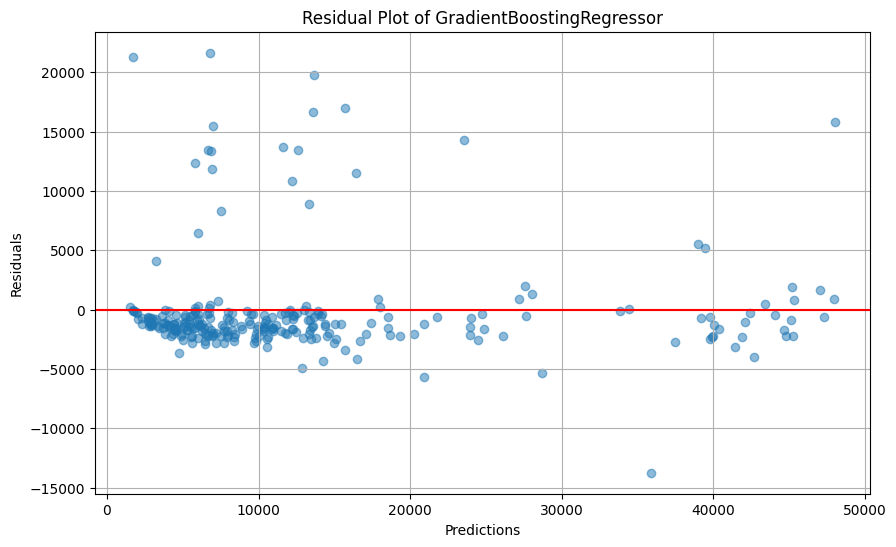

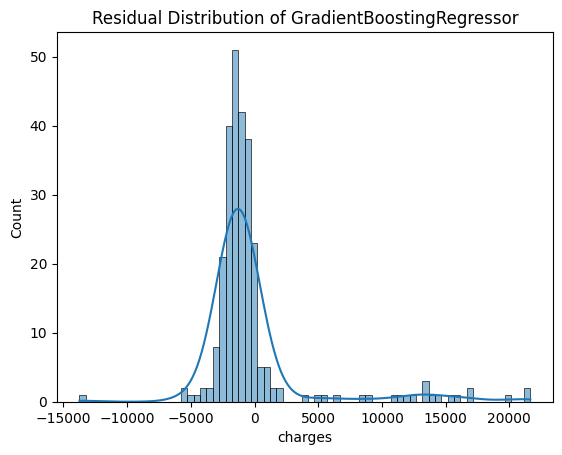

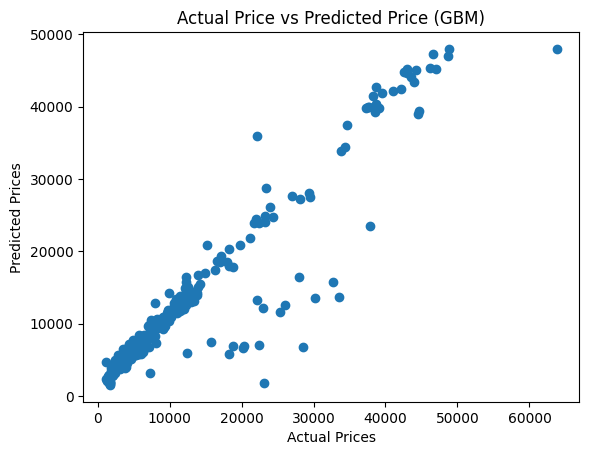

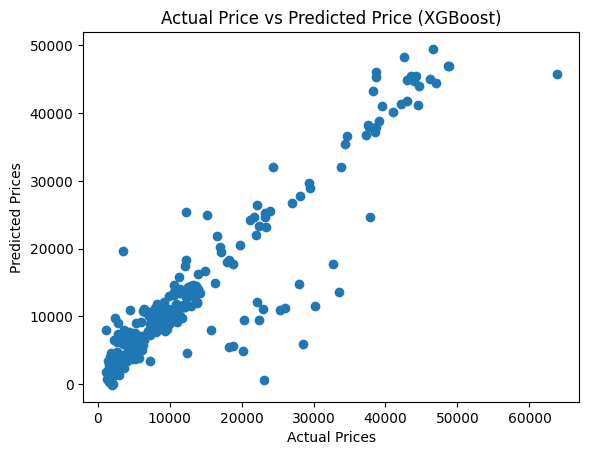

In [19]:
# Visualization: Visualize the model's performance and residuals.

# Gradient Boosting Regressor residuals: Plot the residuals (difference between actual and predicted values) against the predicted values.
# A good residual plot should show randomly scattered points around the horizontal line at zero.
residuals = y_test - test_predict2
plt.figure(figsize=(10, 6))
plt.scatter(test_predict2, residuals, alpha=0.5)
plt.title('Residual Plot of GradientBoostingRegressor')
plt.xlabel('Predictions')
plt.ylabel('Residuals')
plt.axhline(y=0, color='r', linestyle='-') # Add a horizontal line at zero for reference.
plt.grid(True)
plt.show()

# Residual Histogram: Plot a histogram of the residuals to check for normality.
plt.figure() # Create a new figure for the histogram
plt.title('Residual Distribution of GradientBoostingRegressor')
sns.histplot(residuals, kde=True)
plt.show()

# Visualization: Actual vs Predicted for GBM: Scatter plot of actual insurance charges versus predicted charges for the test set.
# Points should ideally fall along the diagonal line.
plt.figure() # Create a new figure for the scatter plot
plt.scatter(y_test, test_predict2)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price (GBM)")
plt.show()


# Visualization: Actual vs Predicted for XGBoost: Scatter plot of actual insurance charges versus predicted charges for the test set.
plt.figure() # Create a new figure for the scatter plot
plt.scatter(y_test, test_data_prediction)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Price vs Predicted Price (XGBoost)")
plt.show()